# Dataset and Environment Setup

- CO(GT): True hourly averaged concentration CO in mg/m^3 - Target feature


In [51]:
import random
import warnings

import numpy as np
import tensorflow as tf

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=UserWarning)

In [52]:
import pandas as pd

raw_df = pd.read_csv(
    "air+quality/AirQualityUCI.csv",
    parse_dates=["Date"],
    date_format="%d/%m/%Y",
    sep=";",
    decimal=",",
)

nan_df = raw_df.replace(-200, np.nan)
nan_df = nan_df.drop(columns=["Unnamed: 15", "Unnamed: 16"])
nan_df = nan_df.dropna(how="all", axis=1)
nan_df = nan_df.dropna(how="all", axis=0)

print(f"Original shape: {raw_df.shape}")
print(f"After dropna shape: {nan_df.shape}\n")
print(f"Column data types\n{nan_df.dtypes}\n")
print(f"Value range for each column\n{nan_df.agg(['min', 'max'])}\n")
print(f"NaN count for each column\n{nan_df.isna().sum()}")

Original shape: (9471, 17)
After dropna shape: (9357, 15)

Column data types
Date             datetime64[us]
Time                        str
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

Value range for each column
          Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
min 2004-03-10  00.00.00     0.1        647.0       7.0       0.1   
max 2005-04-04  23.00.00    11.9       2040.0    1189.0      63.7   

     PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
min          383.0      2.0         322.0      2.0         551.0        221.0   
max         2214.0   1479.0   

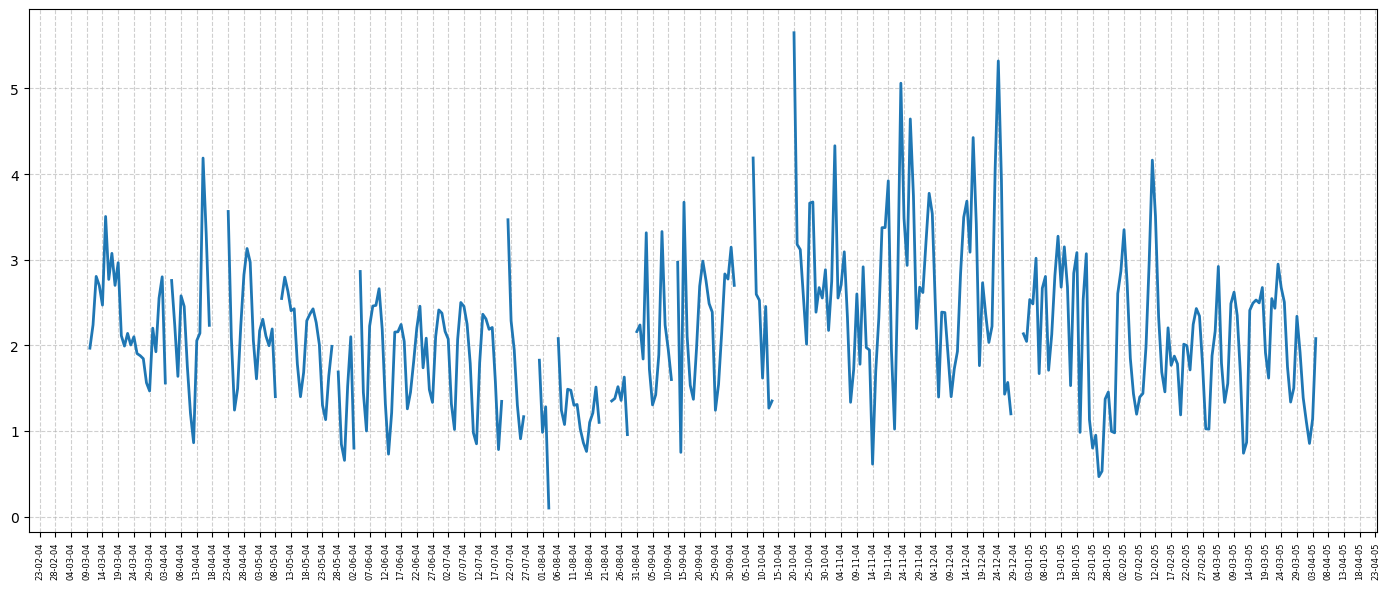

In [53]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

plot_df = nan_df[["Date", "CO(GT)"]].copy().set_index("Date")
plot_df = plot_df.resample("D").mean()
fig, ax = plt.subplots(figsize=(14, 6), layout="tight")
ax.plot(plot_df.index, plot_df.values, linewidth=2, label="Plot")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%y"))
plt.xticks(rotation=90, fontsize=6)
ax.grid(True, linestyle="--", alpha=0.6)

# Data Processing

- Dropped rows/cols: 114 rows (earlier) + 2 unnamed columns (earlier)


In [54]:
DEFAULT_SPLIT = [0.7, 0.15, 0.15]


def split_dataset(
    features: np.ndarray,
    target: np.ndarray,
    split: list | None = None,
):
    ndarray_split = np.array(split)

    if split is None:
        ndarray_split = np.array(DEFAULT_SPLIT)
    elif ndarray_split.shape != (3,):
        raise ValueError("Shape of split array must be (3,)")
    elif ndarray_split.sum() != 1 or ndarray_split.sum != 100:
        raise ValueError("Split percentage must sum to 1 or 100%")

    if ndarray_split.sum() == 100:
        ndarray_split /= 100

    if len(features) != len(target):
        raise ValueError("Lengths of feature set and target set are mismatch")

    total_entries = len(features)
    cumsum_split = np.cumsum(ndarray_split)

    train_stop_index = int(cumsum_split[0] * total_entries)
    val_stop_index = int(cumsum_split[1] * total_entries)

    train_x = features[:train_stop_index]
    train_y = target[:train_stop_index]

    validate_x = features[train_stop_index:val_stop_index]
    validate_y = target[train_stop_index:val_stop_index]

    test_x = features[val_stop_index:]
    test_y = target[val_stop_index:]

    return ((train_x, train_y), (validate_x, validate_y), (test_x, test_y))

In [106]:
# Splitting

working_df = nan_df.drop(columns=["Date", "Time"])
working_df = working_df.interpolate("linear")

target = "CO(GT)"
features = working_df.columns.drop(
    ["NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", target]
).to_list()

df_x = working_df[features]
df_y = working_df[[target]]

((train_x, train_y), (validate_x, validate_y), (test_x, test_y)) = split_dataset(
    features=df_x, target=df_y
)
print(features)

['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']


In [56]:
# Normalizing

from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

train_x = scaler_x.fit_transform(train_x)
train_y = scaler_y.fit_transform(train_y)

validate_x = scaler_x.transform(validate_x)
validate_y = scaler_y.transform(validate_y)

test_x = scaler_x.transform(test_x)
test_y = scaler_y.transform(test_y)

In [57]:
# Sliding window

from keras.utils import timeseries_dataset_from_array

TIME_STEPS = 24
BATCH_SIZE = 32


train_dataset = timeseries_dataset_from_array(
    data=train_x,
    targets=train_y[TIME_STEPS:],
    sequence_length=TIME_STEPS,
    sequence_stride=1,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

validate_dataset = timeseries_dataset_from_array(
    data=validate_x,
    targets=validate_y[TIME_STEPS:],
    sequence_length=TIME_STEPS,
    sequence_stride=1,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_dataset = timeseries_dataset_from_array(
    data=test_x,
    targets=test_y[TIME_STEPS:],
    sequence_length=TIME_STEPS,
    sequence_stride=1,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Models


In [94]:
UNITS = 32
ACTIVATION = "tanh"
DROPOUT = 0.2

In [109]:
# RNN

from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

rnn = Sequential(
    [
        SimpleRNN(
            units=UNITS,
            activation=ACTIVATION,
            input_shape=(TIME_STEPS, train_x.shape[1]),
            recurrent_dropout=DROPOUT,
        ),
        Dropout(DROPOUT),
        Dense(1, kernel_regularizer="l2"),
    ],
    name="RNN",
)

rnn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

rnn.summary()

Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,345 (5.25 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# LSTM

from keras.layers import LSTM

lstm = Sequential(
    [
        LSTM(
            units=UNITS,
            activation=ACTIVATION,
            input_shape=(TIME_STEPS, train_x.shape[1]),
            recurrent_dropout=DROPOUT,
        ),
        Dropout(DROPOUT),
        Dense(1, kernel_regularizer="l2"),
    ],
    name="LSTM",
)

lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

lstm.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

# Training


In [144]:
import time

from keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

EPOCHS = 20


class TrainingTime(Callback):
    def on_train_begin(self, logs=None):
        self.training_time = []

    def on_epoch_begin(self, epoch, logs=None):
        self.start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.start_time
        self.training_time.append(duration)


def create_callback(model_type: str, training_time: TrainingTime):
    if model_type.lower() != "rnn" and model_type.lower() != "lstm":
        raise ValueError("Unknown model type")

    return [
        ModelCheckpoint(
            filepath=f"models/{model_type.lower()}.keras",
            mode="min",
            save_best_only=True,
        ),
        EarlyStopping(patience=20, verbose=1, restore_best_weights=True),
        training_time,
    ]

In [145]:
# RNN training

rnn_training_time = TrainingTime()

rnn_history = rnn.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validate_dataset,
    shuffle=False,
    verbose=1,
    callbacks=create_callback("RNN", training_time=rnn_training_time),
)

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1378 - mae: 0.2631 - val_loss: 0.0236 - val_mae: 0.0857
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0433 - mae: 0.1421 - val_loss: 0.0181 - val_mae: 0.0749
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0248 - mae: 0.1026 - val_loss: 0.0153 - val_mae: 0.0712
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0177 - mae: 0.0847 - val_loss: 0.0137 - val_mae: 0.0710
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0140 - mae: 0.0754 - val_loss: 0.0125 - val_mae: 0.0706
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0119 - mae: 0.0713 - val_loss: 0.0118 - val_mae: 0.0721
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0104 - mae: 0.0675 - val_loss: 0.0110 - val_mae: 0.0714
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0097 - mae: 0.0665 - val_loss: 0.0107 - val_mae: 0.0725
Epoch 9/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - lo

In [146]:
# LSTM training

lstm_training_time = TrainingTime()

lstm_history = lstm.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validate_dataset,
    shuffle=False,
    verbose=1,
    callbacks=create_callback("LSTM", training_time=lstm_training_time),
)

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0328 - mae: 0.1014 - val_loss: 0.0242 - val_mae: 0.0895
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0186 - mae: 0.0789 - val_loss: 0.0176 - val_mae: 0.0845
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0135 - mae: 0.0736 - val_loss: 0.0142 - val_mae: 0.0807
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0112 - mae: 0.0714 - val_loss: 0.0123 - val_mae: 0.0776
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0100 - mae: 0.0695 - val_loss: 0.0114 - val_mae: 0.0761
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0092 - mae: 0.0678 - val_loss: 0.0109 - val_mae: 0.0753
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0087 - mae: 0.0660 - val_loss: 0.0107 - val_mae: 0.0753
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0085 - mae: 0.0652 - val_loss: 0.0103 - val_mae: 0.0736
Epoch 9/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step -

# Evaluation


In [147]:
def get_predicted_metrics(model: Sequential):
    test_predicted = model.evaluate(test_dataset)

    mse, mae = test_predicted

    return (mse, mae)


In [148]:
# RNN evaluation
rnn_mse, rnn_mae = get_predicted_metrics(rnn)

print(f"RNN MSE: {rnn_mse:.4f}")
print(f"RNN MAE: {rnn_mae:.4f}")

rnn_predicted_y_scaled = rnn.predict(test_dataset)
rnn_predicted_y = scaler_y.inverse_transform(rnn_predicted_y_scaled)

true_y_scaled = np.concatenate([y for x, y in test_dataset], axis=0)
true_y = scaler_y.inverse_transform(true_y_scaled)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0080 - mae: 0.0719
RNN MSE: 0.0080
RNN MAE: 0.0719
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [149]:
# LSTM evaluation

lstm_mse, lstm_mae = get_predicted_metrics(lstm)

print(f"LSTM MSE: {lstm_mse:.4f}")
print(f"LSTM MAE: {lstm_mae:.4f}")

lstm_predicted_y_scaled = lstm.predict(test_dataset)
lstm_predicted_y = scaler_y.inverse_transform(lstm_predicted_y_scaled)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0076 - mae: 0.0689
LSTM MSE: 0.0076
LSTM MAE: 0.0689
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [163]:
from keras.callbacks import History


def generate_loss_plots(
    model_history: History, model_type: str, figsize: tuple = (20, 6)
):
    _, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].plot(
        model_history.history["loss"],
        label=f"{model_type} Train MSE",
        color="red",
        linewidth=2,
    )

    axes[0].plot(
        model_history.history["val_loss"],
        label=f"{model_type} Validation MSE",
        color="orange",
        linewidth=2,
        linestyle=":",
    )

    axes[1].plot(
        model_history.history["mae"],
        label=f"{model_type} Train MAE",
        color="purple",
        linewidth=2,
    )

    axes[1].plot(
        model_history.history["val_mae"],
        label=f"{model_type} Validation MAE",
        color="blue",
        linewidth=2,
        linestyle=":",
    )

    axes[0].set_title("Training vs. Validation Loss", fontsize=14)
    axes[1].set_title("Training vs. Validation MAE", fontsize=14)
    axes[0].set_xlabel("Epochs", fontsize=12)
    axes[1].set_xlabel("Epochs", fontsize=12)
    axes[0].legend(loc="upper right")
    axes[1].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


def generate_CO_values_plots(
    predicted_y: np.ndarray,
    model_type: str,
    samples: int = 300,
    figsize: tuple = (20, 6),
):
    _, axes = plt.subplots(1, 1, figsize=figsize)

    axes.plot(true_y[:samples], label="True CO(GT)", color="green", linewidth=2)
    axes.plot(
        predicted_y[:samples],
        label="Predicted CO(GT)",
        color="blue",
        linewidth=2,
        alpha=0.4,
        linestyle="--",
    )

    axes.set_title(
        f"{model_type} True vs. Predicted CO(GT)\nSamples: First {samples}h",
        fontsize=14,
    )
    axes.set_xlabel("Time steps", fontsize=12)
    axes.legend(loc="upper right")
    axes.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

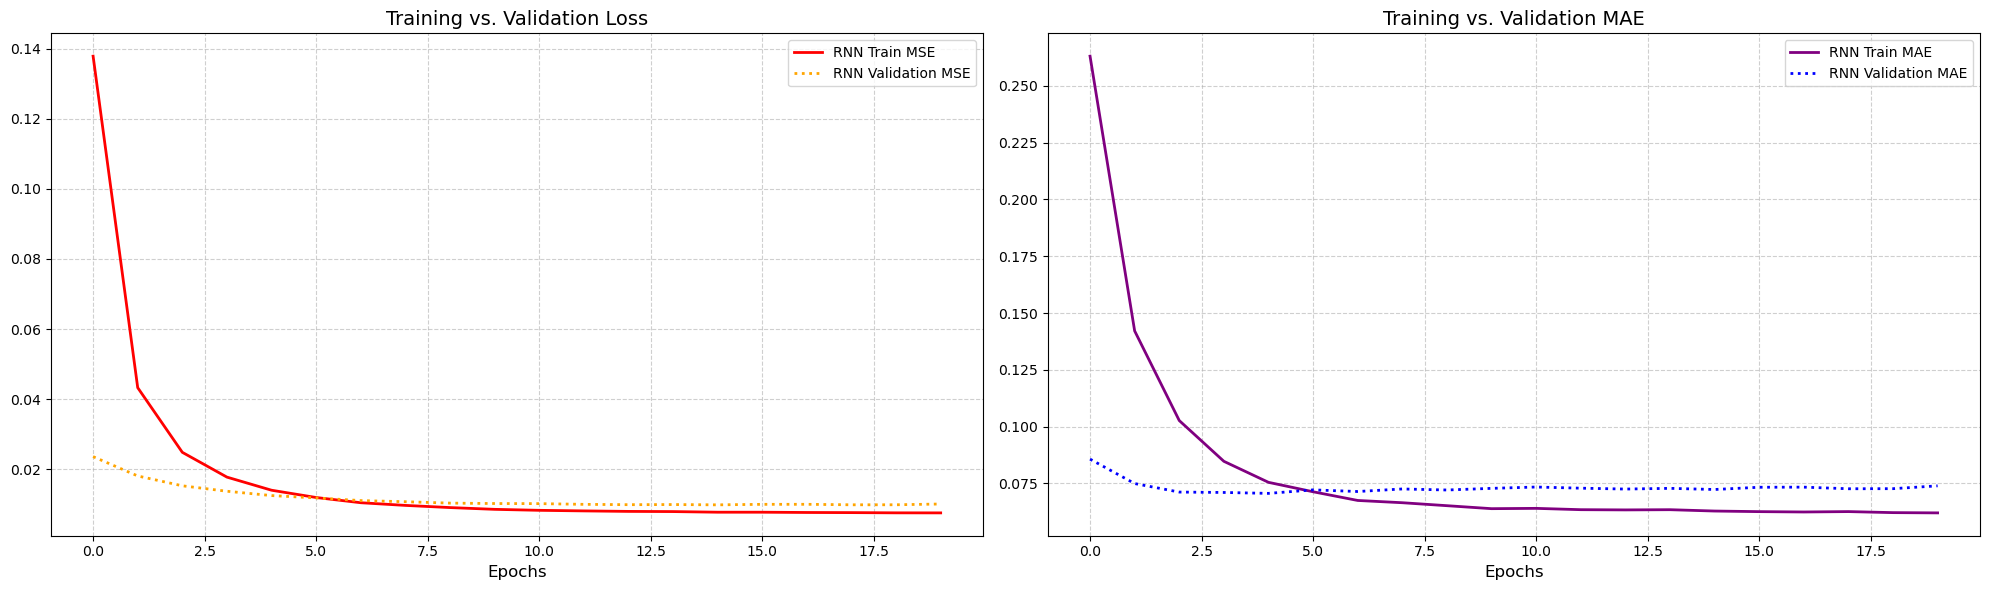

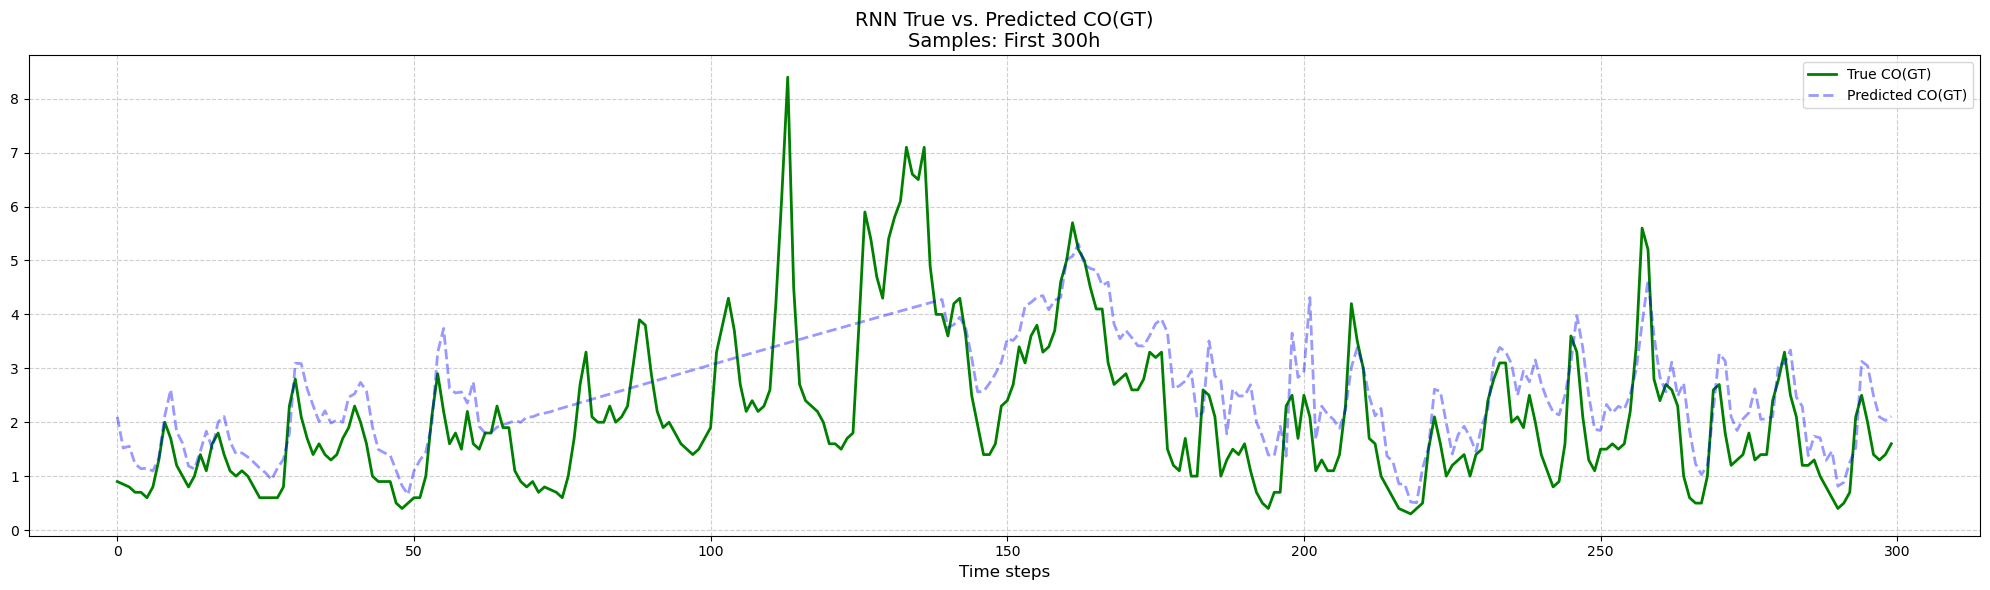

In [164]:
# RNN plots

generate_loss_plots(rnn_history, model_type="RNN")
generate_CO_values_plots(rnn_predicted_y, model_type="RNN")

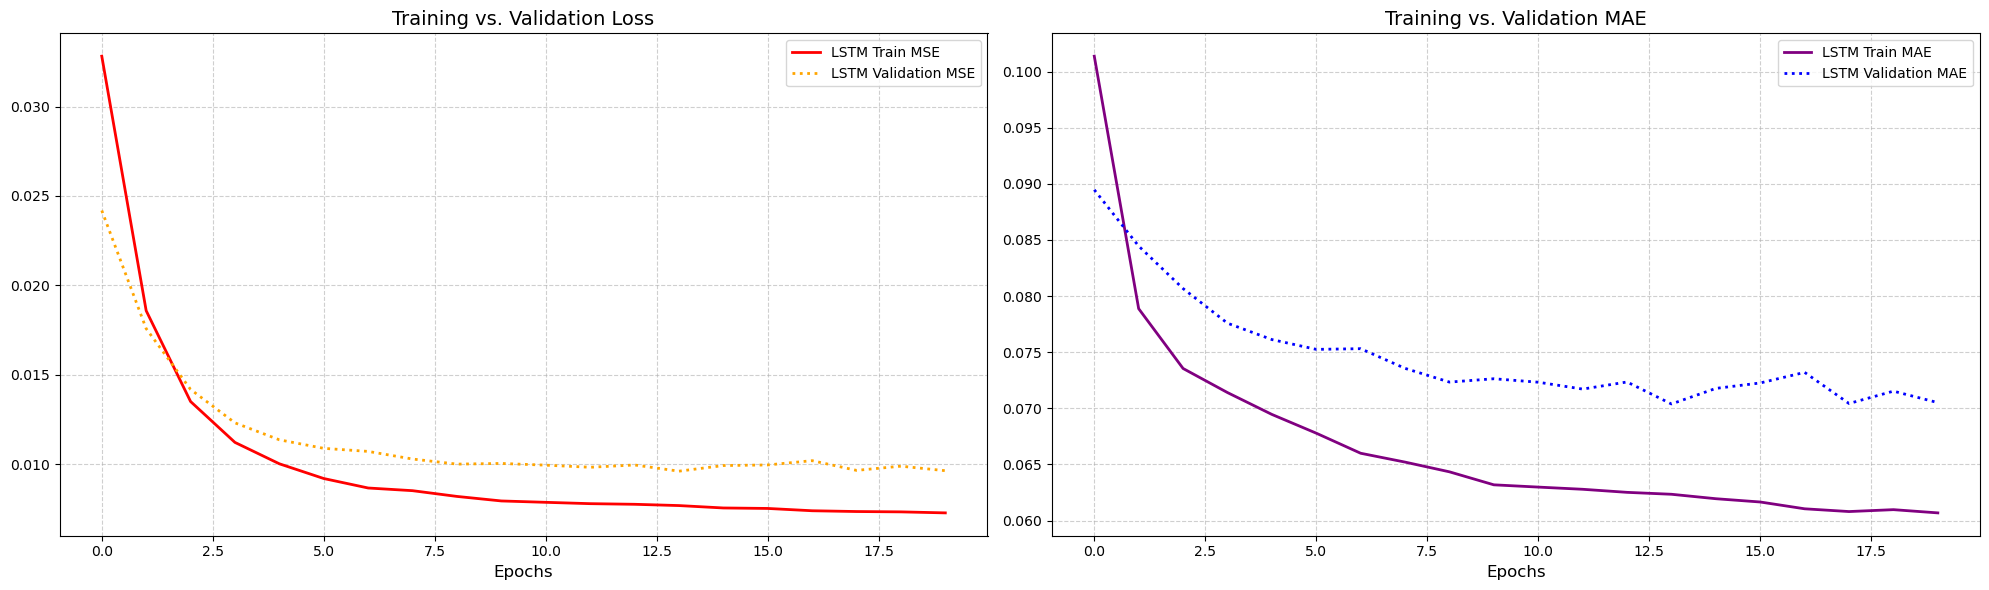

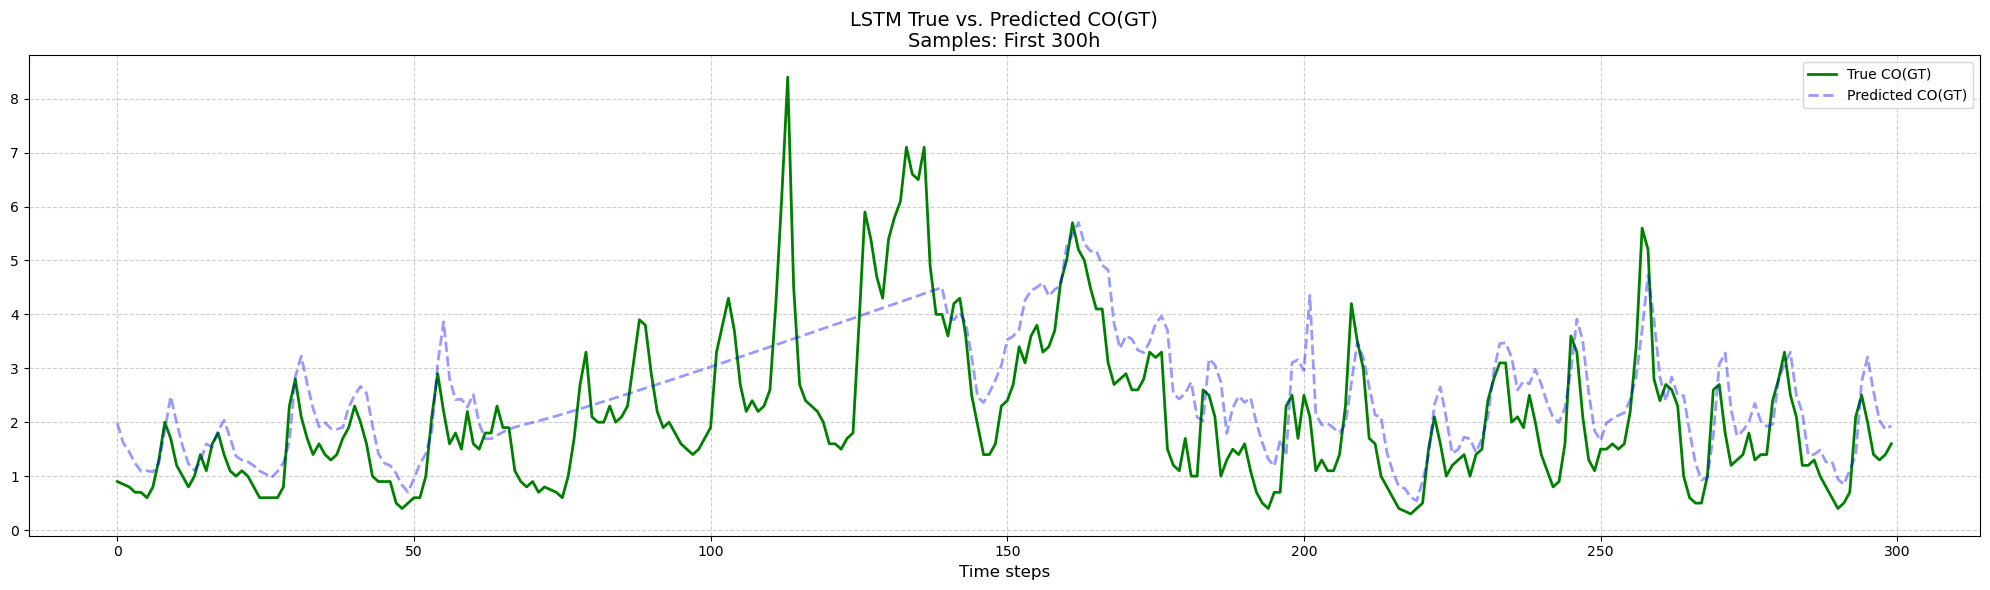

In [165]:
# LSTM plots

generate_loss_plots(lstm_history, model_type="LSTM")
generate_CO_values_plots(lstm_predicted_y, model_type="LSTM")

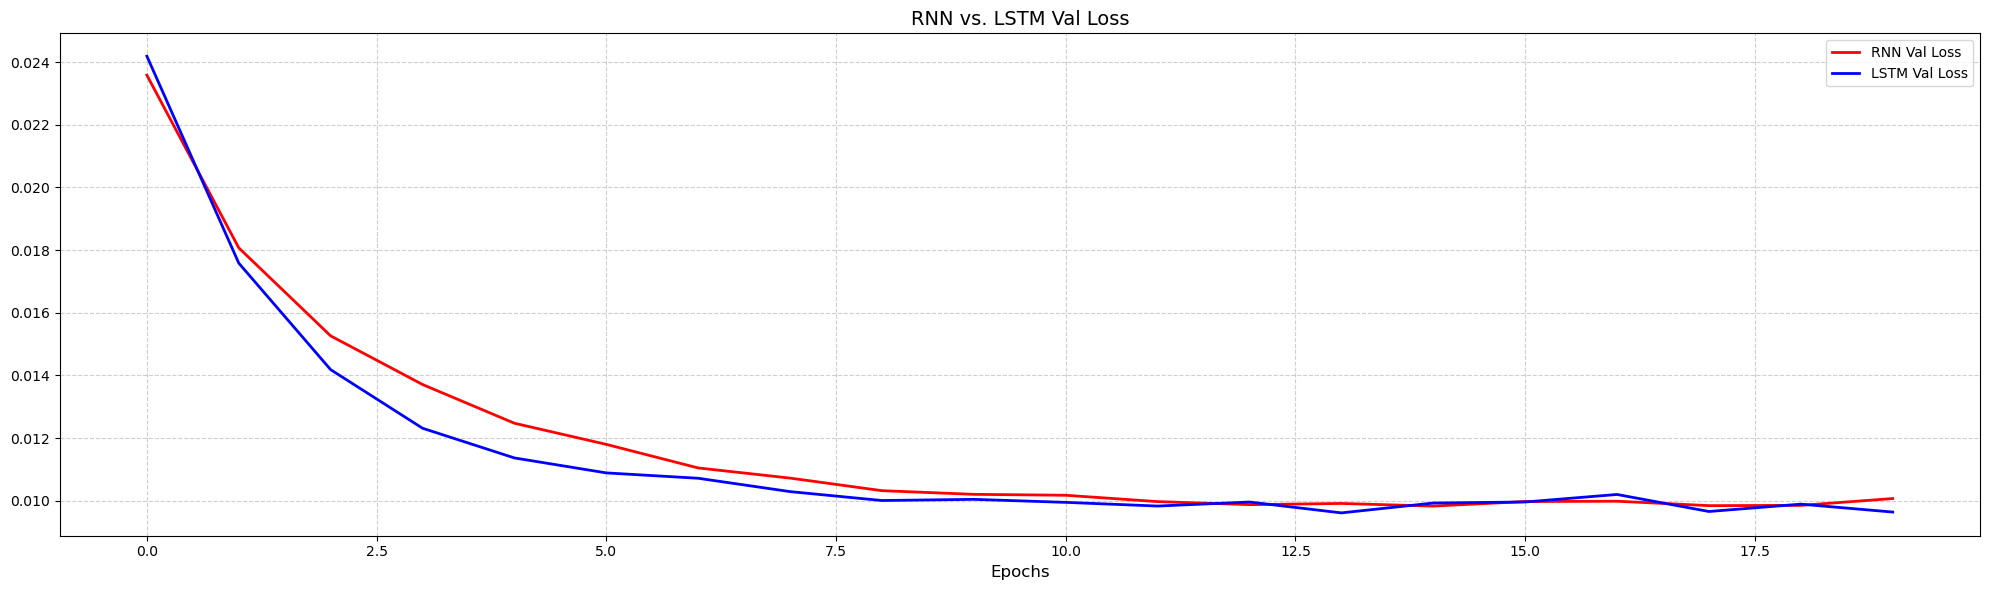

In [166]:
def plot_validation_loss_overlay(figsize: tuple = (20, 6)):
    rnn_val_loss = rnn_history.history["val_loss"]
    lstm_val_loss = lstm_history.history["val_loss"]

    _, axes = plt.subplots(1, 1, figsize=figsize)

    axes.plot(rnn_val_loss, label="RNN Val Loss", color="red", linewidth=2)
    axes.plot(lstm_val_loss, label="LSTM Val Loss", color="blue", linewidth=2)

    axes.set_title(
        "RNN vs. LSTM Val Loss",
        fontsize=14,
    )
    axes.set_xlabel("Epochs", fontsize=12)
    axes.legend(loc="upper right")
    axes.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


plot_validation_loss_overlay()

# Model Comparison


In [167]:
def create_table(rnn_cols: list, lstm_cols: list):
    data = {"Epochs": np.arange(1, 21), "RNN": rnn_cols, "LSTM": lstm_cols}
    return pd.DataFrame(data)


def generate_loss_table():
    rnn_training_loss = rnn_history.history["loss"]
    lstm_training_loss = lstm_history.history["loss"]
    df_training = create_table(rnn_training_loss, lstm_training_loss)
    print("Training Loss")
    print(df_training)

    print("\n")

    rnn_val_loss = rnn_history.history["val_loss"]
    lstm_val_loss = lstm_history.history["val_loss"]
    df_val = create_table(rnn_val_loss, lstm_val_loss)
    print("Validation Loss")
    print(df_val)

    print("\n")

    test_table = {
        "Model": ["RNN", "LSTM"],
        "Test Loss": [rnn_mse, lstm_mse],
        "Test MAE": [rnn_mae, lstm_mae],
    }

    df_test_table = pd.DataFrame(test_table)
    print(df_test_table)


generate_loss_table()

Training Loss
    Epochs       RNN      LSTM
0        1  0.137847  0.032819
1        2  0.043261  0.018586
2        3  0.024814  0.013507
3        4  0.017740  0.011219
4        5  0.014001  0.010023
5        6  0.011921  0.009200
6        7  0.010431  0.008670
7        8  0.009669  0.008520
8        9  0.009049  0.008199
9       10  0.008546  0.007946
10      11  0.008265  0.007869
11      12  0.008098  0.007794
12      13  0.007956  0.007759
13      14  0.007906  0.007687
14      15  0.007727  0.007553
15      16  0.007725  0.007526
16      17  0.007648  0.007398
17      18  0.007611  0.007354
18      19  0.007546  0.007335
19      20  0.007533  0.007278


Validation Loss
    Epochs       RNN      LSTM
0        1  0.023583  0.024189
1        2  0.018071  0.017583
2        3  0.015261  0.014183
3        4  0.013709  0.012313
4        5  0.012472  0.011365
5        6  0.011798  0.010887
6        7  0.011046  0.010716
7        8  0.010721  0.010290
8        9  0.010320  0.010006
9      

In [168]:
rnn.summary()
lstm.summary()

Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_8 (SimpleRNN)        │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,037 (15.77 KB)

 Trainable params: 1,345 (5.25 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 32)             │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,845 (61.90 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,564 (41.27 KB)

In [169]:
rnn_avg_training_time = np.array(rnn_training_time.training_time).mean()
lstm_avg_training_time = np.array(lstm_training_time.training_time).mean()

df_avg_training_time = pd.DataFrame(
    {
        "Model": ["RNN", "LSTM"],
        "Avg. Training Time (s/epoch)": [rnn_avg_training_time, lstm_avg_training_time],
    }
)

print(df_avg_training_time)

  Model  Avg. Training Time (s/epoch)
0   RNN                      1.048130
1  LSTM                      2.092078


# Saving/Loading Models

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


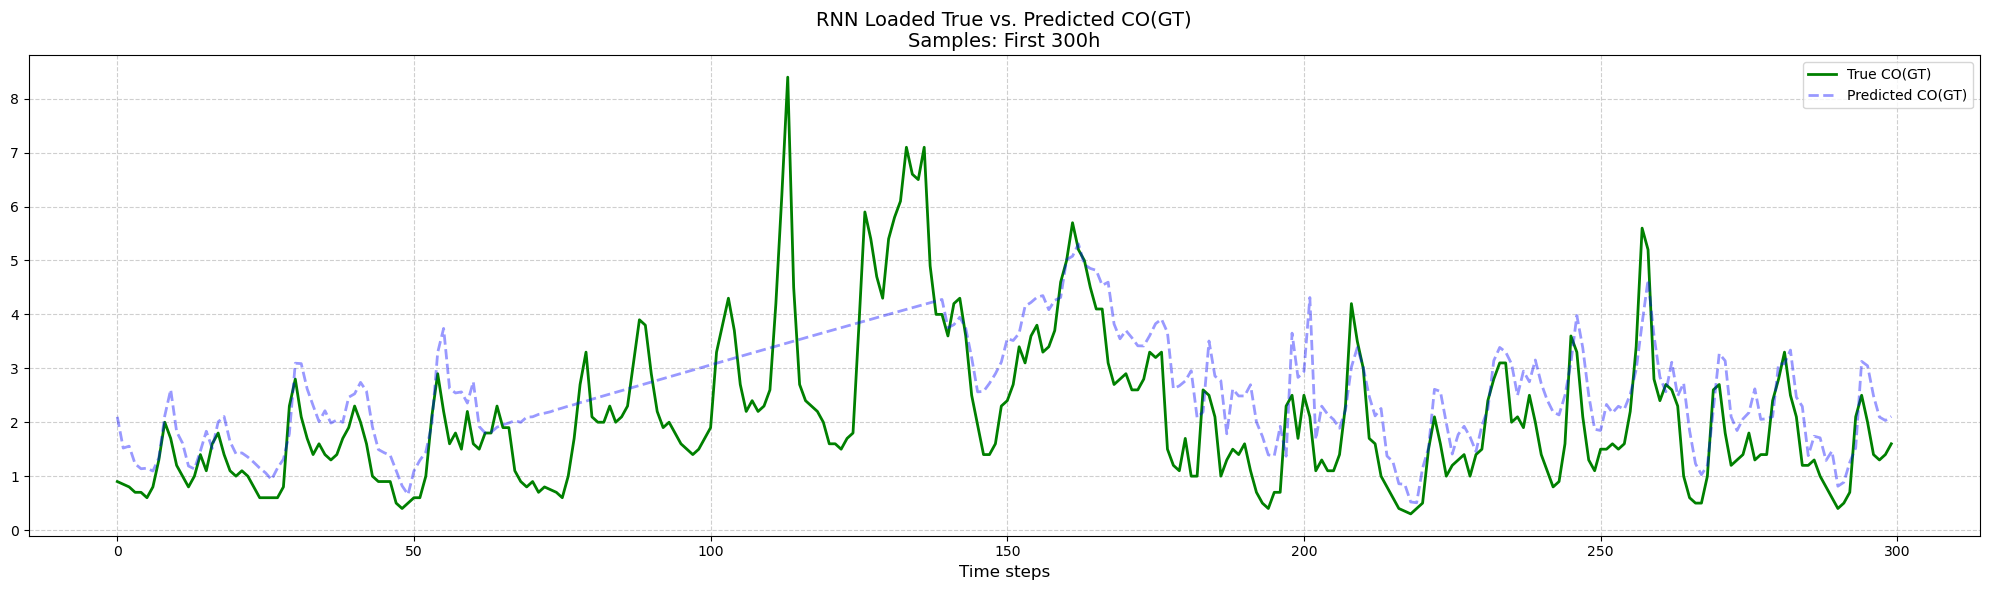

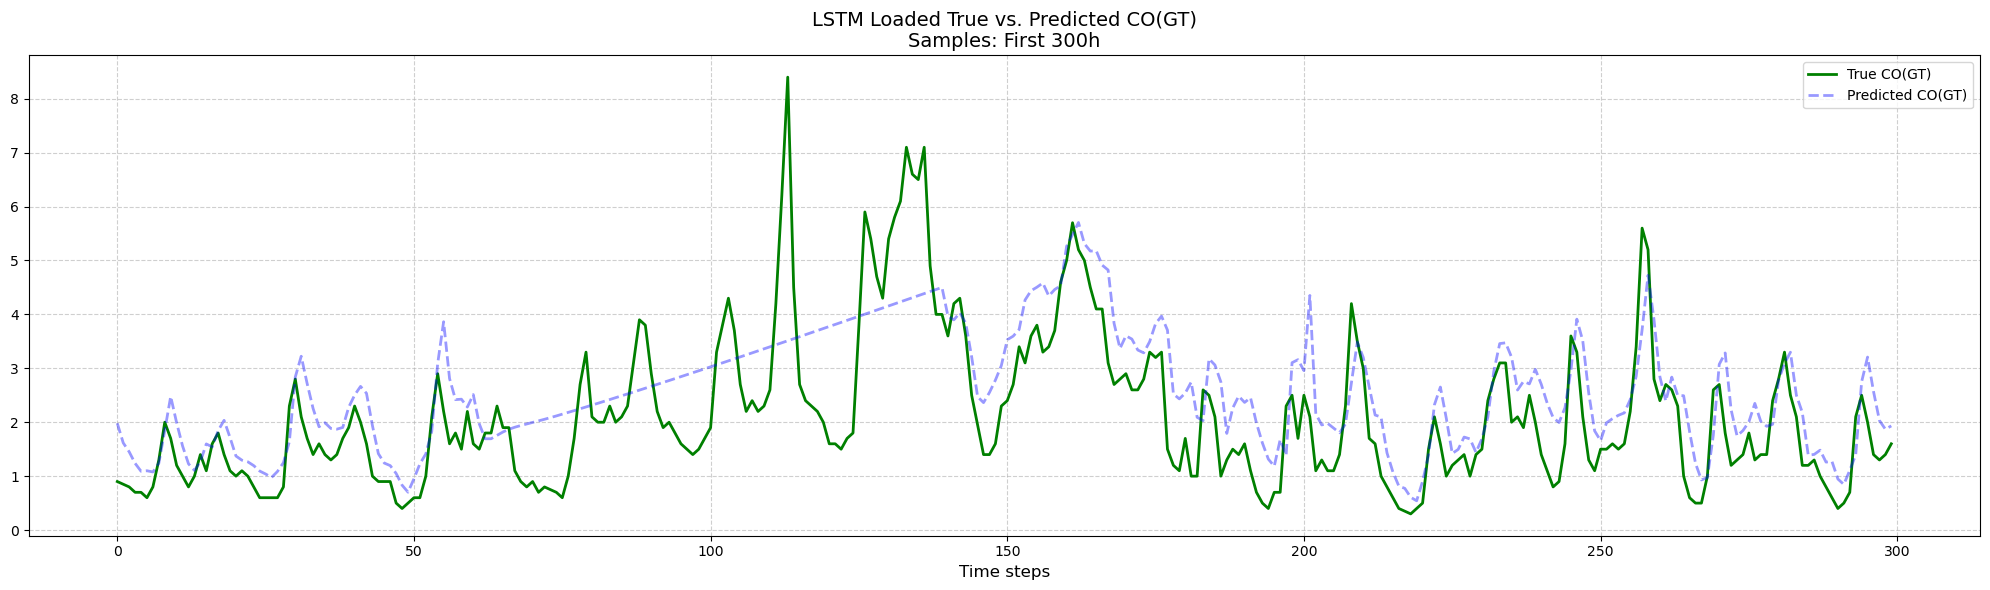

In [170]:
from keras.models import load_model

rnn_loaded = load_model("models/rnn.keras")
lstm_loaded = load_model("models/lstm.keras")

rnn_loaded_predicted = rnn.predict(test_dataset)
rnn_loaded_predicted = scaler_y.inverse_transform(rnn_loaded_predicted)

lstm_loaded_predicted = lstm.predict(test_dataset)
lstm_loaded_predicted = scaler_y.inverse_transform(lstm_loaded_predicted)

generate_CO_values_plots(rnn_loaded_predicted, model_type="RNN Loaded")
generate_CO_values_plots(lstm_loaded_predicted, model_type="LSTM Loaded")